<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
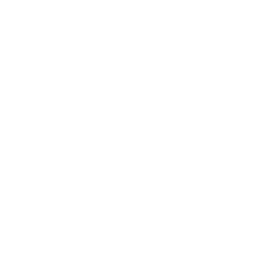
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Semiconductor Yield and Defect Root Cause Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Semiconductor Manufacturing / Process Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A semiconductor fab runs two wafer-sort lines, FAB1 and FAB2. FAB1's
average gross die yield has slipped and engineering needs to know
*which process tool* is responsible before authorizing a corrective
maintenance action. This notebook uses **PROC SQL** end to end to
isolate the root cause: a `UNION ALL` set operator stacks the two
lines into one analysis table, a `GROUP BY` summarizes yield and
inline defect density per tool, and an `INNER JOIN` to the equipment
maintenance log plus a `HAVING` clause with a correlated subquery
surfaces the single tool whose defect density is statistically
elevated above its fab baseline.

The analysis runs on 100 wafer-sort records (60 from FAB1, 40 from
FAB2). It finds that **FAB1 averages 83.13% yield versus 89.02% for
FAB2**, and pins the gap on **tool CVD-02**, which averages
**73.45% yield** against ~89-90% for every other tool while carrying
roughly double the defect density (**0.2215** vs ~0.11). CVD-02 is
**58 days past a 30-day preventive-maintenance interval**, making an
emergency PM the indicated corrective action.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| `WORK.WAFER_SORT_FAB1` | Wafer-sort yield and inline defect density, FAB1 | 60 |
| `WORK.WAFER_SORT_FAB2` | Wafer-sort yield and inline defect density, FAB2 | 40 |
| `WORK.EQUIPMENT_LOG` | Process-tool maintenance log (PM timing) | 6 |

All three tables are synthesized in the DATA steps below with fixed
random seeds, so every figure in this notebook is reproducible. The
analysis fits within the 100-observation limit of an unlicensed
session: CVD-02 is intentionally over-represented in FAB1 so its
yield excursion is unambiguous at this sample size.

---

### Build the wafer-sort tables

FAB1 draws from three tools — CVD-01, CVD-02, ETH-01 — and CVD-02 is
given an engineered yield excursion (mean 74% versus 90% for the
healthy tools) along with an elevated defect-density offset. FAB2 is
a clean baseline line with three of its own tools.

In [1]:
data work.wafer_sort_fab1;
    call streaminit(42);
    length fab_id $4 lot_id $10 tool_id $6 recipe $6 shift $5;
    array tools[3] $6 _temporary_
        ('CVD-01' 'CVD-02' 'ETH-01');
    array recipes[2] $6 _temporary_ ('RCP_A1' 'RCP_B1');
    do lot_seq = 1 to 60;
        fab_id   = 'FAB1';
        lot_id   = cat('FAB1-', put(lot_seq, z4.));
        tool_id  = tools[int(rand('uniform') * 3) + 1];
        recipe   = recipes[int(rand('uniform') * 2) + 1];
        shift    = ifc(rand('uniform') < 0.5, 'DAY', 'NIGHT');
        /* CVD-02 carries an engineered yield excursion */
        if tool_id = 'CVD-02' then
            gross_die_yield =
                round(rand('normal', 0.74, 0.03), 0.0001);
        else
            gross_die_yield =
                round(rand('normal', 0.90, 0.02), 0.0001);
        gross_die_yield = max(0, min(1, gross_die_yield));
        defect_density  = max(0, round(
            rand('normal', 0.12, 0.02)
            + (tool_id = 'CVD-02') * 0.10, 0.0001));
        output;
    end;
    drop lot_seq;
    format gross_die_yield percent8.2;
run;

data work.wafer_sort_fab2;
    call streaminit(77);
    length fab_id $4 lot_id $10 tool_id $6 recipe $6 shift $5;
    array tools[3] $6 _temporary_
        ('CVD-11' 'ETH-11' 'IMP-11');
    array recipes[2] $6 _temporary_ ('RCP_C1' 'RCP_D1');
    do lot_seq = 1 to 40;
        fab_id   = 'FAB2';
        lot_id   = cat('FAB2-', put(lot_seq, z4.));
        tool_id  = tools[int(rand('uniform') * 3) + 1];
        recipe   = recipes[int(rand('uniform') * 2) + 1];
        shift    = ifc(rand('uniform') < 0.5, 'DAY', 'NIGHT');
        gross_die_yield = max(0, min(1,
            round(rand('normal', 0.89, 0.02), 0.0001)));
        defect_density  = max(0,
            round(rand('normal', 0.11, 0.02), 0.0001));
        output;
    end;
    drop lot_seq;
    format gross_die_yield percent8.2;
run;

NOTE: DATA work.wafer_sort_fab1


NOTE: Wrote work.wafer_sort_fab1 (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA work.wafer_sort_fab2


NOTE: Wrote work.wafer_sort_fab2 (40 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


### Equipment maintenance log

One row per process tool, recording how many days have elapsed since
the last preventive maintenance (PM) and the scheduled PM interval.
CVD-02 is 58 days into a 30-day interval — 28 days overdue.

In [2]:
data work.equipment_log;
    length tool_id $6 fab_id $4 tool_type $3;
    infile datalines dsd;
    input tool_id $ fab_id $ tool_type $
          days_since_pm pm_interval_days;
    datalines;
CVD-01,FAB1,CVD,21,45
CVD-02,FAB1,CVD,58,30
ETH-01,FAB1,ETH,12,45
CVD-11,FAB2,CVD,18,45
ETH-11,FAB2,ETH,9,45
IMP-11,FAB2,IMP,15,45
;
run;

NOTE: DATA work.equipment_log

NOTE: Processing inline DATALINES (6 lines)

NOTE: Read 6 rows from DATALINES.
NOTE: Wrote work.equipment_log (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

### Step 1 — `UNION ALL`: stack both fab lines

A set operator combines the two wafer-sort tables into one
analysis-ready table, `WORK.COMBINED_YIELD`. `UNION ALL` keeps every
row (no de-duplication), which is what yield analysis needs — each
wafer is a distinct observation.

In [3]:
proc sql;
    create table work.combined_yield as
    select fab_id, lot_id, tool_id, recipe, shift,
           gross_die_yield, defect_density
    from work.wafer_sort_fab1
    union all
    select fab_id, lot_id, tool_id, recipe, shift,
           gross_die_yield, defect_density
    from work.wafer_sort_fab2;
quit;

NOTE: PROC SQL 

NOTE: Table work.combined_yield created.
NOTE: PROC SQL statement used.


### Step 2 — `GROUP BY`: yield baseline per fab line

Aggregating the combined table by `fab_id` quantifies the gap between
the two lines and confirms FAB1 is the problem.

In [4]:
proc sql;
    title 'Average gross die yield by fab line';
    select fab_id,
           count(*)                  as n_wafers,
           mean(gross_die_yield)*100 as avg_yield  format=6.2,
           std(gross_die_yield)*100  as std_yield  format=6.2,
           min(gross_die_yield)*100  as min_yield  format=6.2
    from work.combined_yield
    group by fab_id;
quit;

fab_id  n_wafers  avg_yield  std_yield  min_yield
------  --------  ---------  ---------  ---------
  FAB1        60      83.13       8.22      68.77
  FAB2        40      89.02       2.39      83.34


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


FAB1 averages **83.13%** yield with a wide spread (std **8.22**,
minimum **68.77%**), while FAB2 holds a tight **89.02%** (std
**2.39**). The high FAB1 variance is the signature of a single
misbehaving tool dragging the line down rather than a broad process
shift — the next step isolates it.

### Step 3 — `GROUP BY` by tool: find the outlier

Summarizing yield and defect density per tool exposes which tool is
responsible for FAB1's excursion.

In [5]:
proc sql;
    title 'Yield and defect density by process tool';
    select tool_id, fab_id,
           count(*)                  as n_wafers,
           mean(gross_die_yield)*100 as avg_yield format=6.2,
           mean(defect_density)      as avg_defect_density
               format=6.4
    from work.combined_yield
    group by tool_id, fab_id
    order by avg_yield;
quit;

tool_id  fab_id  n_wafers  avg_yield  avg_defect_density
-------  ------  --------  ---------  ------------------
 CVD-02    FAB1        24      73.45              0.2215
 ETH-11    FAB2        12      88.57              0.1118
 CVD-11    FAB2        14      89.20              0.1105
 IMP-11    FAB2        14      89.23              0.1074
 ETH-01    FAB1        19      89.42              0.1209
 CVD-01    FAB1        17      89.77              0.1161


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


The ranking is decisive. **CVD-02 averages 73.45% yield** across its
24 wafers — about 16 points below every other tool, which all cluster
at 88.6%-89.8%. CVD-02 also carries the highest defect density at
**0.2215**, roughly double the ~0.11-0.12 seen elsewhere. Yield and
defect density agree: CVD-02 is the root cause.

### Step 4 — `INNER JOIN` + `HAVING`: confirm against the maintenance log

The final query joins the per-tool defect data to the equipment log
and applies a `HAVING` clause with a correlated subquery: keep only
tools whose mean defect density exceeds their own fab's average by
more than 0.03. This is the statistical gate that promotes a tool to
a corrective-action request.

In [6]:
proc sql;
    title 'Tools with statistically elevated defect density';
    select c.tool_id,
           e.fab_id,
           e.tool_type,
           e.days_since_pm,
           e.pm_interval_days,
           count(*)                    as n_wafers,
           mean(c.gross_die_yield)*100 as avg_yield format=6.2,
           mean(c.defect_density)      as avg_defect_density
               format=6.4
    from work.combined_yield c
    inner join work.equipment_log e
        on c.tool_id = e.tool_id
    group by c.tool_id, e.fab_id, e.tool_type,
             e.days_since_pm, e.pm_interval_days
    having mean(c.defect_density) >
        (select mean(c2.defect_density) + 0.03
         from work.combined_yield c2
         inner join work.equipment_log e2
             on c2.tool_id = e2.tool_id
         where e2.fab_id = e.fab_id)
    order by avg_defect_density descending;
quit;

tool_id  fab_id  tool_type  days_since_pm  pm_interval_days  n_wafers  avg_yield  avg_defect_density
-------  ------  ---------  -------------  ----------------  --------  ---------  ------------------
 CVD-02    FAB1        CVD           58.0              30.0        24      73.45              0.2215


NOTE: PROC SQL 

NOTE: PROC SQL statement used.


Exactly one tool clears the threshold: **CVD-02** (FAB1, CVD type),
defect density **0.2215**, yield **73.45%**. The join brings in the
smoking gun — CVD-02 is **58 days since its last PM against a 30-day
interval**, 28 days overdue. The correlated subquery confirms this is
elevation relative to FAB1's own baseline, not a cross-fab artifact.

---

### Visualize the yield excursion

A bar of average yield per tool, with the 80% yield-floor reference
line, makes the excursion obvious at a glance.

NOTE: PROC SQL 

NOTE: Table work.tool_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.tool_summary

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


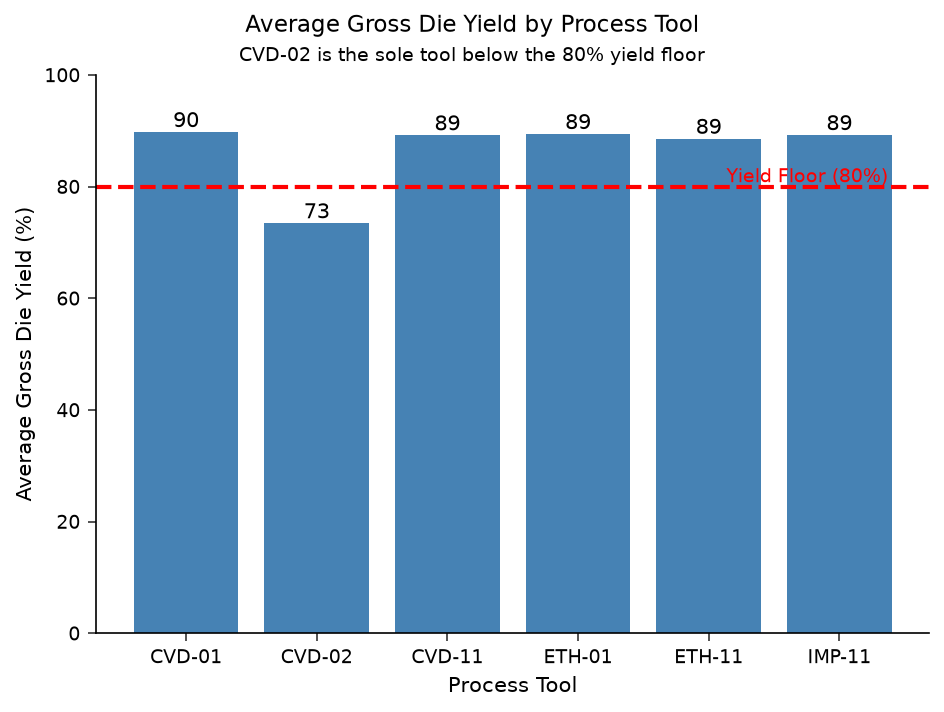

In [7]:
proc sql;
    create table work.tool_summary as
    select tool_id, fab_id,
           mean(gross_die_yield)*100 as avg_yield,
           mean(defect_density)      as avg_defect_density
    from work.combined_yield
    group by tool_id, fab_id
    order by avg_yield;
quit;

proc sgplot data=work.tool_summary;
    title 'Average Gross Die Yield by Process Tool';
    title2 'CVD-02 is the sole tool below the 80% yield floor';
    vbar tool_id / response=avg_yield
        datalabel datalabelattrs=(size=9)
        fillattrs=(color=cx4682b4);
    refline 80 / axis=y
        lineattrs=(pattern=dash color=red thickness=2)
        label='Yield Floor (80%)';
    yaxis label='Average Gross Die Yield (%)'
        values=(0 to 100 by 20);
    xaxis label='Process Tool';
run;

### Interpretation

The PROC SQL pipeline turns 100 raw wafer-sort records into an
actionable root-cause finding using only set operators, joins, and
grouped aggregation:

- **`UNION ALL`** combined 60 FAB1 and 40 FAB2 wafers into a single
  100-row analysis table.
- **`GROUP BY` at the fab level** showed FAB1 at **83.13%** mean yield
  versus FAB2 at **89.02%**, with FAB1's std of **8.22** signalling a
  localized rather than systemic problem.
- **`GROUP BY` at the tool level** isolated **CVD-02 at 73.45%** yield
  and **0.2215** defect density, an outlier against the ~89% / ~0.11
  baseline of all five other tools.
- **`INNER JOIN` + `HAVING` with a correlated subquery** confirmed
  CVD-02 as the only tool exceeding its fab's defect-density baseline
  by more than 0.03, and linked it to a PM that is **28 days overdue**
  (58 days elapsed on a 30-day interval).

**Recommended corrective action:** schedule an emergency preventive
maintenance and recipe re-qualification for CVD-02. The flagged wafer
list is exported below to feed the downstream SPC dashboard.

### Export the flagged wafers

The CVD-02 wafer-sort records are written to CSV for the statistical
process-control follow-up.

In [8]:
proc sql;
    create table work.cvd02_excursions as
    select lot_id, tool_id, gross_die_yield, defect_density
    from work.combined_yield
    where tool_id = 'CVD-02'
    order by gross_die_yield;
quit;

proc export data=work.cvd02_excursions
    outfile='cvd02_excursions.csv'
    dbms=csv replace;
run;

NOTE: PROC SQL 

NOTE: Table work.cvd02_excursions created.
NOTE: PROC SQL statement used.
NOTE: PROC EXPORT data=work.cvd02_excursions outfile=cvd02_excursions.csv

NOTE: Exported 24 rows to cvd02_excursions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>